# Exploring bird diversity with AviList
## Date: 2026-05-12
tags:
  - AviList
  - ornithology
  - birds
  - taxonomy
  - conservation

![AviList title image](/images/data-science/avilist/title.png)

Bird taxonomy dates back to 1758 when Carl Linnaeus, the "father of modern taxonomy", recognized 554 species of birds in the tenth edition of *Systema Naturae*. Since then the birds (which in taxonomy are represented by the class *Ave*) have become, by far, the most thoroughly described and well-characterized taxonomic class on the planet with over 10,000 species described. Furthermore, there is good reason to believe that the current species count is vanishingly close to the true global count unlike the current counts for other terrestrial vertebrate groups - mammals (6495 sp), reptiles (11,440 sp), and amphibians (8301 sp) - which are known to be severely undercounted. Despite how well studied they are, there has not always been global consensus on how to classify the various species, genuses, and even orders of birds. Over the last 50 or so years, modern bird taxonomy has been simultaneously described by 4 comprehensive (yet often conflicting) checklists, the two most popular of which are the [Clements Checklist of Birds of the World](https://www.birds.cornell.edu/clementschecklist) (used by the Cornell Lab of Ornithology) and the [International Ornithological Community (IOC) World Bird List](https://www.worldbirdnames.org/new/). 

Back in 2018, ornithologists representing all the world's major zoogeographic regions convened at the International Ornithological Congress in Vancouver to consolidate modern bird taxonomy into a single harmonized list, and in July 2025, **[AviList](https://www.avilist.org/)** was released (see original publication in [Biodiversity and Conservation, 2025](https://link.springer.com/article/10.1007/s10531-025-03120-y)). With global consensus, the first release of the AviList contains **11,131 bird species across 2376 genera, 252 families, and 46 orders**.

![Indochinese-Roller](https://drive.google.com/thumbnail?id=1vL-BvdXWxK5bc5C8pzx6UcHow0oC93i-&sz=w1000)
<br>
_Photo I took of an Indochinese Roller (Coracias affinis) at Angkor Wat in 2024_

Having spent a good chunk of 2025 birding in Southeast Asia and South America, I was excited to dig into this new checklist when I returned from sabbatical and see what I could learn about bird taxonomy, evolution, geography, and conservation. So, I downloaded the [AviList v2025 checklist (11 Jun, extended)](https://www.avilist.org/checklist/v2025/) and decided to generate this data science writeup using Jupyter Notebook to better understand it. I've organized this notebook into the following sections:

1. **History**
2. **Taxonomy**
3. **Evolution**
4. **Geography**
5. **Conservation**


## Setup, data preparation, and dataset overview

<details markdown="1" class="avilist-setup-code">
<summary>Setup code: imports, paths, and plotting defaults</summary>



In [1]:
from __future__ import annotations

import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns

try:
    from IPython.display import HTML, display
except ImportError:
    display = print
    HTML = lambda x: x


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if not (cand / "requirements.txt").exists():
            continue
        if (cand / "python" / "birds_nb.py").is_file():
            return cand
        if (cand / "birds_nb.py").is_file():
            return cand
    return p


REPO_ROOT = _repo_root()
_py = REPO_ROOT / "python"
if (_py / "birds_nb.py").is_file():
    sys.path.insert(0, str(_py))

from birds_nb import (
    CONTINENT_DISPLAY,
    family_label,
    genus_label,
    order_label,
    sp_region_label,
    sunburst_panzoom_viewport,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130

DATA_DIR = REPO_ROOT / "data" if (REPO_ROOT / "data").is_dir() else REPO_ROOT
AVILIST_XLSX = DATA_DIR / "AviList-v2025-11Jun-extended.xlsx"
LIFELIST_CSV = DATA_DIR / "RWY_ebird_world_life_list.csv"
CACHE = DATA_DIR / ".cache_avilist.pkl.gz"
for p in (AVILIST_XLSX, LIFELIST_CSV):
    assert p.exists(), f"Missing {p}"
print(f"AviList {AVILIST_XLSX.name} ({AVILIST_XLSX.stat().st_size/1e6:.1f} MB) | list {LIFELIST_CSV.name} ({LIFELIST_CSV.stat().st_size/1e3:.1f} KB)")
# Geography choropleth: set EBIRD_API_KEY (free) — https://ebird.org/api/keygen


AviList AviList-v2025-11Jun-extended.xlsx (8.9 MB) | list RWY_ebird_world_life_list.csv (171.8 KB)


</details>


### Data loading and preparation

<details markdown="1" class="avilist-setup-code">
<summary>Setup code: load AviList and derive species tables</summary>



In [2]:
from birds_nb import add_genus_common_example, continents_in, countries_in, load_avilist, regions_in

YEAR_RE = re.compile(r"(1[5-9]\d{2}|20\d{2})")

def _yr(v):
    if not isinstance(v, str):
        return np.nan
    m = YEAR_RE.search(v)
    return float(m[1]) if m else np.nan

# Load + derive all Step 1 working columns in one place.
df_all = load_avilist(AVILIST_XLSX, CACHE)
df_all["Description_year"] = df_all["Authority"].map(_yr)
df_all["Genus"] = df_all["Scientific_name"].astype(str).str.split().str[0]

iucn_order = ["LC", "NT", "VU", "EN", "CR", "EW", "EX", "DD", "NE"]
raw_iucn = df_all["IUCN_Red_List_Category"].fillna("NE").astype(str).str.strip()
raw_iucn = raw_iucn.str.replace(r"^CR.*", "CR", regex=True).where(raw_iucn.isin(iucn_order), "NE")
df_all["IUCN"] = pd.Categorical(raw_iucn, categories=iucn_order, ordered=True)

extinct_raw = df_all["Extinct_or_possibly_extinct"].astype(str).str.strip().str.lower()
df_all["is_extinct"] = extinct_raw.isin({"extinct", "possibly extinct", "yes", "true", "1"}) | df_all["IUCN"].isin(["EX", "EW"])

df_species = df_all[df_all["Taxon_rank"] == "species"].copy().reset_index(drop=True)
df_species = add_genus_common_example(df_species)
df_family = df_all[df_all["Taxon_rank"] == "family"].copy().reset_index(drop=True)
df_order = df_all[df_all["Taxon_rank"] == "order"].copy().reset_index(drop=True)

df_species["Range_continents"] = df_species["Range"].map(continents_in)
df_species["Range_regions"] = df_species["Range"].map(regions_in)
df_species["Range_countries"] = df_species["Range"].map(countries_in)
df_species["N_continents"] = df_species["Range_continents"].map(len)

parsed = (df_species["N_continents"] > 0).sum()
country_parsed = (df_species["Range_countries"].map(len) > 0).sum()
print(
    f"Loaded {len(df_all):,} rows | orders {len(df_order)} | families {len(df_family)} | "
    f"genera {df_species['Genus'].nunique():,} | species {len(df_species):,} | "
    f"continent parsed {parsed:,}/{len(df_species):,} | "
    f"country parsed {country_parsed:,}/{len(df_species):,}"
)


Loaded 33,684 rows | orders 46 | families 252 | genera 2,376 | species 11,131 | continent parsed 5,726/11,131 | country parsed 5,163/11,131


</details>


<details markdown="1" class="avilist-setup-code">
<summary>Setup code: rank counts and dataset overview</summary>



In [3]:
rank_counts = pd.Series({
    "Order": (df_all["Taxon_rank"] == "order").sum(),
    "Family": (df_all["Taxon_rank"] == "family").sum(),
    "Genus": df_species["Genus"].nunique(),
    "Species": (df_all["Taxon_rank"] == "species").sum(),
    "Subspecies": (df_all["Taxon_rank"] == "subspecies").sum(),
})
richest_families = (
    df_species.groupby(["Order", "Family", "Family_English_name"], dropna=False)
    .size().reset_index(name="n_species")
    .sort_values("n_species", ascending=False)
)
richest_orders = (
    df_species.groupby("Order").size()
    .reset_index(name="n_species")
    .sort_values("n_species", ascending=False).head(10)
)


</details>


## 1) History

In this section we're going to jump in and start exploring the AviList, beginning with some history! One fun thing about the extended data version of AviList is that it has **tons** of metadata so we can ask questions like when and by whom were the most bird species described?

### When were these species described?

Based ont the plots below, the golden age of bird identification was the 19<sup>th</sup> century in which the number of identified birds worldwide exploded from ~2000 to ~10,000. Although the subsequent 20<sup>th</sup> and 21<sup>st</sup> centuries saw a rise in the popularity of recreational birding, the global species count would only rise another ~10% between 1900 and the present (supporting the view that there remain less and less undiscovered species).

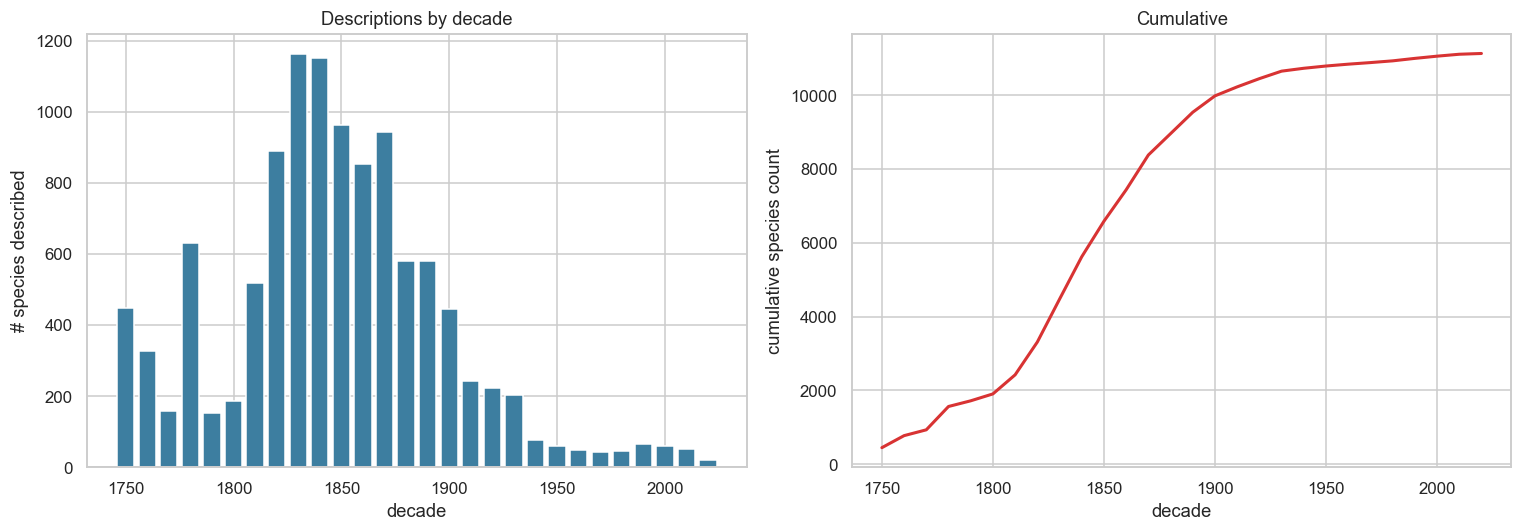

In [4]:
year_df = df_species.dropna(subset=["Description_year"]).copy()
year_df["decade"] = (year_df["Description_year"] // 10 * 10).astype(int)
counts = year_df["decade"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(counts.index, counts.values, width=8, color="#3d7ea0")
axes[0].set(xlabel="decade", ylabel="# species described", title="Descriptions by decade")
axes[1].plot(counts.index, counts.cumsum(), lw=2, color="#d83333")
axes[1].set(xlabel="decade", ylabel="cumulative species count", title="Cumulative")
plt.tight_layout()
plt.show()


This is not to say that there remain no undiscovered bird species; I extracted the 5 latest species that wwere added to the AviList and printed them below. As you can see, ornithologists and recreational birders are still discovering new species (though interestingly all 5 of the latest discoveries were found in the Malay Archipelago).

In [5]:
print("5 most recent:")
cols = ["Scientific_name", "English_name_AviList", "Family", "Description_year", "Authority"]
for geo in ("Region", "Regions", "Distribution", "Range", "Location", "Geography", "Countries"):
    if geo in year_df.columns:
        cols.append(geo)
        break


def abbrev_authority(x):
    if pd.isna(x):
        return x
    first = str(x).split(";")[0].strip()
    return f"{first} et al." if first else x


recent = year_df.sort_values("Description_year", ascending=False)[cols].head(5).copy()
recent["Authority"] = recent["Authority"].map(abbrev_authority)
recent["Description_year"] = pd.to_numeric(recent["Description_year"], errors="coerce").astype("Int64")
recent

5 most recent:


,Scientific_name,English_name_AviList,Family,Description_year,Authority,Range
2164,Caprimulgus ritae,Timor Nightjar,Caprimulgidae,2024,"King, BF et al.","Timor, Rote, and Wetar (eastern Lesser Sundas)"
8186,Zosterops paruhbesar,Wangi-wangi White-eye,Zosteropidae,2023,"Irham, M et al.","Wangi-wangi, Wakatobi (Tukangbesi) Islands, off southeastern Sulawesi"
8169,Zosterops meratusensis,Meratus White-eye,Zosteropidae,2022,"Irham, M et al.","Meratus Mountains, South Kalimantan, southeastern Borneo"
2836,Otus bikegila,Principe Scops Owl,Strigidae,2022,"Melo, M et al.",Príncipe Island (Gulf of Guinea)
9146,Cyornis kadayangensis,Meratus Blue Flycatcher,Muscicapidae,2022,"Irham, M et al.","Meratus Mountains, South Kalimantan, southeastern Borneo"


### Who were the most prolific discoverers?

Our old friend Car Linnaeus easily takes the top spot for discovering over 700 bird species; in fact Linnaeus described ~280 new species in 1758 alone. If you've ever gone birding, getting ~280 new lifers in a year is already pretty respectable so it's crazy to think that Linnaeus managed to **discover** ~280 previously unknown species in a year!

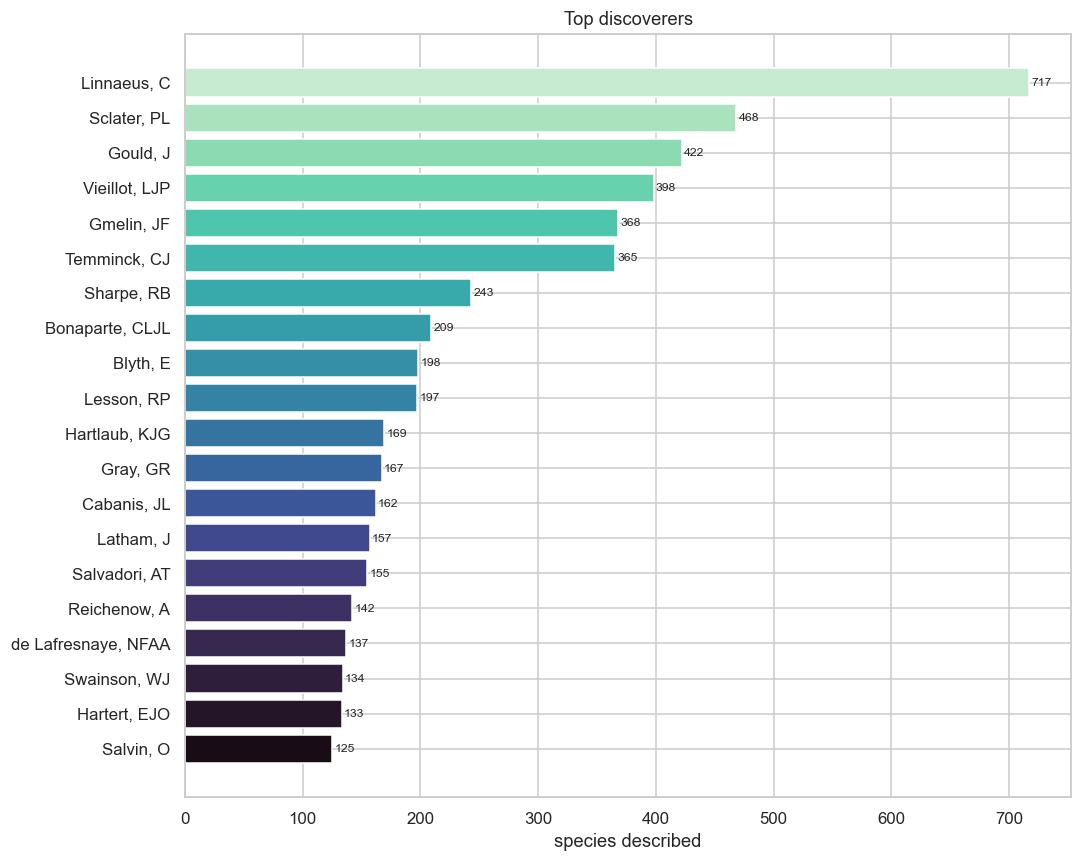

In [6]:
from birds_nb import describer_name

df_species["Describer"] = df_species["Authority"].map(describer_name)
top_describers = df_species.query("Describer != ''")["Describer"].value_counts().head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_describers.index, top_describers.values, color=sns.color_palette("mako", n_colors=20))
for i, v in enumerate(top_describers.values):
    ax.text(v + 2, i, str(int(v)), va="center", fontsize=8)
ax.set(xlabel="species described", title="Top discoverers")
plt.tight_layout()
plt.show()


A fun part of looking over this plot is recognizing the names of some of the explorers from birds Sara and I have seen. For example, although I know nothing about Coenraad Jacob Temminck the man (I had to google him to learn he was an 18<sup>th</sup> century Dutch zoologist), I do recognize the name from the Temminck's Sunbird _(Aethopyga temminckii)_ and Temminck's Babbler _(Pellorneum pyurogenys)_, both of which we saw in Borneo in 2025. As a side note, there's an ongoing movement advocating that these types of birds should be renamed to something more descriptive/anatomical instead of all being named after dead white European men... time will tell!

## 2) Taxonomy

Now let's jump into the bird list itself! To explore this yourself, you can visit this hyperlink **[AviList v2025 checklist (11 Jun, extended)](https://www.avilist.org/checklist/v2025/)** to download the ~33,000 row excel spreadsheet and take a look at the raw data.

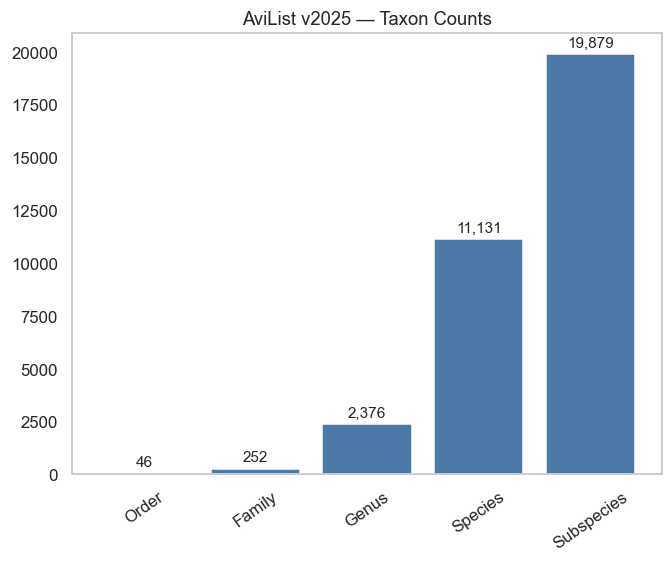

In [7]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
bars = ax.bar(rank_counts.index, rank_counts.values, color="#4C78A8")
ax.set(title="AviList v2025 — Taxon Counts", xticklabels=rank_counts.index)
ax.tick_params(axis="x", rotation=35)
ax.grid(False)
for bar in bars:
    ax.annotate(f"{int(bar.get_height()):,}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=10)
plt.show()

The newly harmonized AviList has **46 orders, 252 families, 2376 genuses, and 11,131 species**. Fun fact: the world's most prolific (and perhaps greatest?) birder, Peter Kaestner has a life list of 10,036 at the time of writing this and was [the first birder to cross the 10K threshold](https://www.aba.org/peter-kaestner-breaks-the-10000-bird-barrier/) on February 9, 2024; given that the ceiling is now set at 11,131 species, Kaestner has seen ~90.2% of all bird species since his first checklist in 1957 nearly 70 years ago.

### Species richness rankings

Just knowing how many species there are isn't particularly exciting, I want to use the AviList to gain a better understand of species diversity and distribution. So beloww we'll separate out the top Orders and Families by species count.

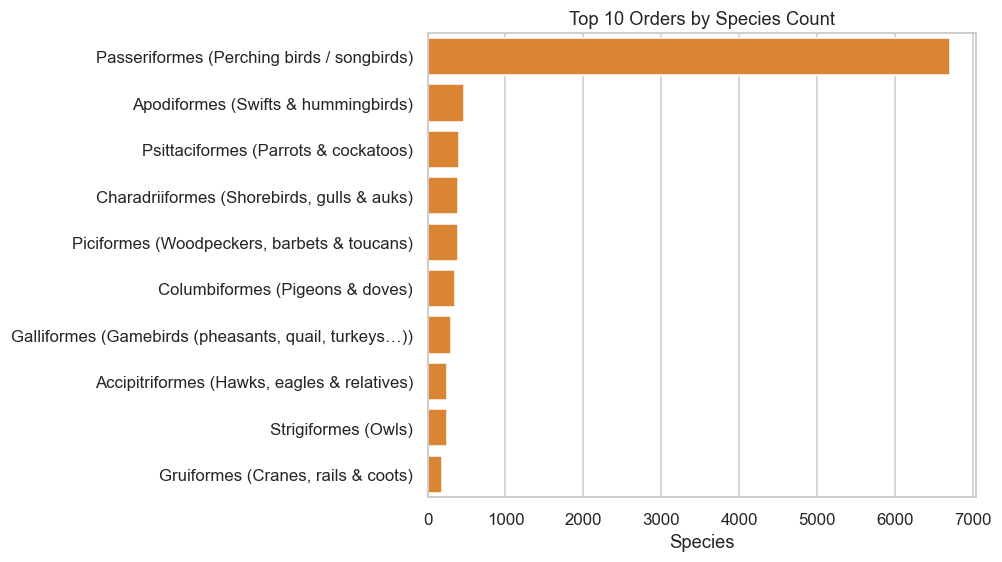

In [8]:
order_labels = [order_label(o) for o in richest_orders["Order"]]

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.barplot(data=richest_orders, y=order_labels, x="n_species", ax=ax, color="#F58518")
ax.set_title("Top 10 Orders by Species Count")
ax.set_xlabel("Species")
ax.set_ylabel("")
plt.show()


As you can see above, the Passeriformes order **absolutely dominates** species count, accounting for ~60% of all global species. Birds of the order Passeriformes (from the Latin "sparrow-shaped") are more comonly known as passerines or perching birds, and include some North American favorites such as the American Robin _(Turdus migratorius)_, Northern Cardinal _(Cardinalis cardinalis)_, and Black-capped Chickadee _(Poecile atricapillus)_

A natural question follows: **why are there so many passerines**? For some reason, evolution has accelerated speciation of this Order and/or buffered these lineages against extinction. The dominance of the Passeriformes Order (an event referred to as "passerine superradiation") is a classic subject of study and debate in evolutionary biology; the truth behind their global diversity is likely to be some synergistic combination of the following leading hypotheses:
- the evolution of their extraordinatry vocal abilities created a complex and diverse set of mating criteria resulting in reproductive isolation thus accelerating speciation
- their morphological perching adaptation (anisodactyly) conferred a huge competitive advantage, allowing them to easily dwell and build their nests in trees thus minimizing predation
- that dispersion to the Wallacean islands in the Malay Archipelago (30-40 Ma) from where they evolved in Australia ~47 Ma provided frequent opportunity for speciation (similar to Darwin's finches)

So the next time a song sparrow is perching and singing a melody at your birdfeeder, take a moment to appreciate that these two adaptations were likely among the key reasons that perching songbirds dominate bird diversity!

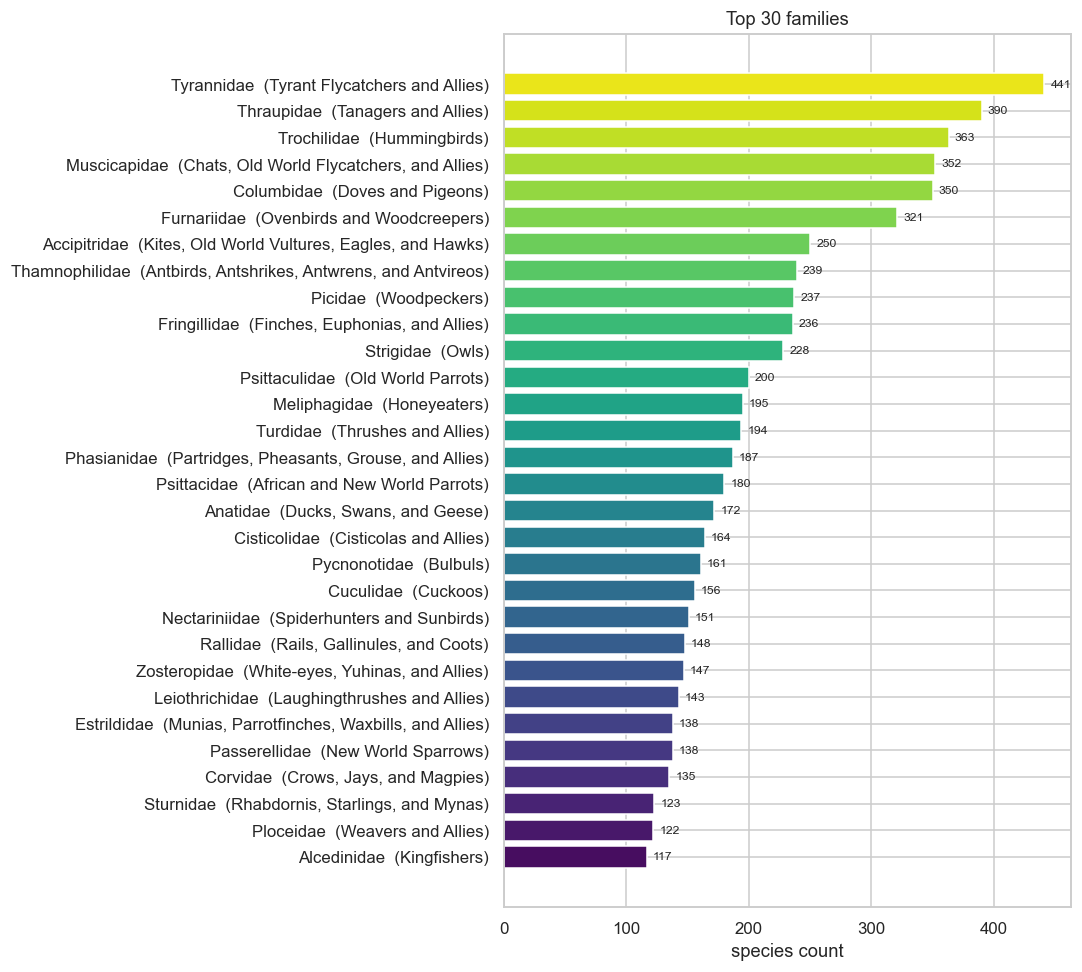

In [9]:
top_fam = richest_families.head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_fam["Family"] + "  (" + top_fam["Family_English_name"].fillna("") + ")", top_fam["n_species"], color=sns.color_palette("viridis", n_colors=30))
for i, v in enumerate(top_fam["n_species"]):
    ax.text(v + 5, i, str(int(v)), va="center", fontsize=8)
ax.set_xlabel("species count")
ax.set_title("Top 30 families")
plt.tight_layout()
plt.show()


I next looked at the top 30 bird families by species count which is not nearly as overwhelmed by a single category as bird orders. Interesting to see that Flycatchers (one of my favorite bird families) and Tanagers (another of my favorite bird families) are among the most numerous. Hummingbirds come as no surprise to anyone who has visited South America and seen the mind-boggling diversity of hummingbirds everywhere but there are some surprises in this list too like Thamnophilidae (Antbirds, Antshrikes, Antwrens, and Antvireos) ranking so high! Perhaps this just surprises me because of how frustratingly difficult these birds are to find in the wild.

### Genus size distribution

One taxonomic rung up from species are genera, and I was curious to ask whether most bird genera contain many different species or whether they only have a handful.

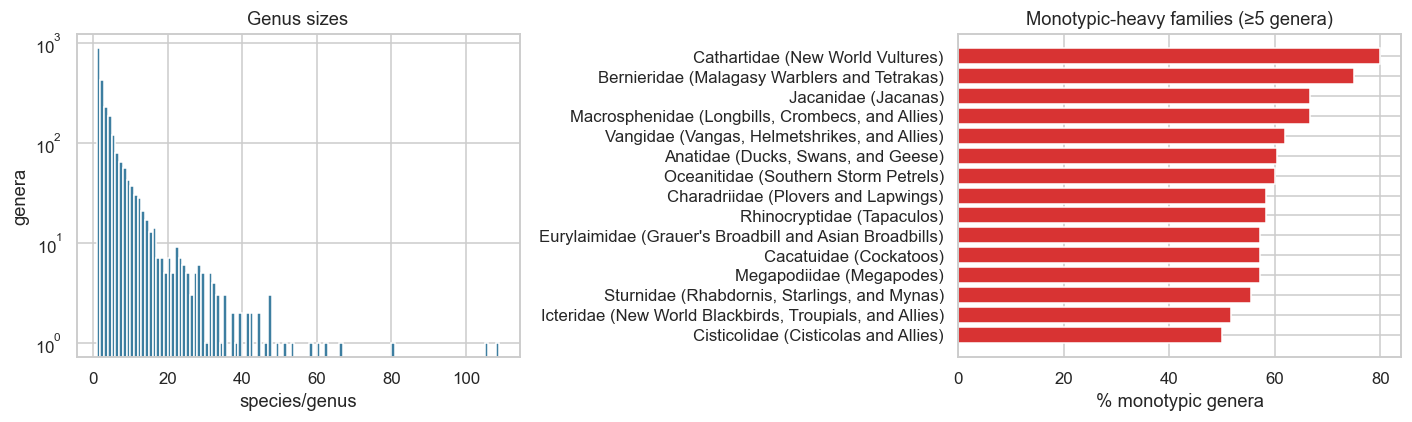

In [10]:
gen_sizes = df_species.groupby("Genus").size().values
mono = (
    df_species.groupby(["Family", "Genus"]).size().reset_index(name="n").assign(monotypic=lambda d: d["n"] == 1)
    .groupby("Family").agg(n_genera=("Genus", "size"), n_mono=("monotypic", "sum")).assign(pct_mono=lambda d: d["n_mono"] / d["n_genera"] * 100)
    .query("n_genera >= 5").sort_values("pct_mono", ascending=False).head(15).iloc[::-1]
)
fe = df_family.set_index("Scientific_name")["Family_English_name"].to_dict()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(gen_sizes, bins=range(1, int(gen_sizes.max()) + 2), color="#3d7ea0")
axes[0].set(xlabel="species/genus", ylabel="genera", yscale="log", title="Genus sizes")
axes[1].barh([family_label(f, fe.get(f, "")) for f in mono.index], mono["pct_mono"], color="#d83333")
axes[1].set(xlabel="% monotypic genera", title="Monotypic-heavy families (≥5 genera)")
plt.tight_layout()
plt.show()


It turns out that most bird genera are tiny — and hundreds are monotypic (a single species). Interpreting what this means can be challenging: often it can be due to extreme specialization but it can also reflect sole survivors of a once diverse lineage (as in the case of vultures and the osprey) or even just be due to taxonomic splitting by modern ornithologists. On the other hand, there exist a handful of mega-genera (e.g. *Zosterops* white-eyes, *Myzomela* honeyeaters) that dominate the tail of the distribution. These mega-genera are often due to ther emergence of "general" evolutionary adaptations that confer an evolutionary advantage but are flexible enough to generalize to a great number of ecological niches.

### Interactive sunburst plot

Using an interactive **sunburst** plot gives us a nice way to explore the AviList: each ring is a finer rank (Order → Family → Genus), and wedge size corresponds to species count. Click a wedge to drill into that branch and click the center ring of the plot to jump back toward the full tree.

<details markdown="1" class="avilist-setup-code">
<summary>Show code — interactive sunburst</summary>



In [11]:
sb_df = (
    df_species.groupby(["Order", "Family", "Genus"], dropna=False)
    .agg(n_species=("Scientific_name", "size"), Family_English_name=("Family_English_name", "first"), Genus_common_example=("Genus_common_example", "first"))
    .reset_index()
)
sb_df["Order_plot"] = sb_df["Order"].map(order_label)
sb_df["Family_plot"] = [family_label(f, e) for f, e in zip(sb_df["Family"], sb_df["Family_English_name"])]
sb_df["Genus_plot"] = [genus_label(g, h) for g, h in zip(sb_df["Genus"], sb_df["Genus_common_example"])]

fig = px.sunburst(
    sb_df,
    path=["Order_plot", "Family_plot", "Genus_plot"],
    values="n_species",
    color="Order",
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Sunburst Order→Family→Genus",
    width=900,
    height=900,
)

trace = fig.data[0]
id_to_parent = dict(zip(trace.ids, trace.parents))
id_to_label = dict(zip(trace.ids, trace.labels))

orders = []
families = []
genera = []

for node_id in trace.ids:
    parent_id = id_to_parent.get(node_id, "")
    if not parent_id:
        order_plot = id_to_label.get(node_id, "")
        family_plot = ""
        genus_plot = ""
    else:
        grandparent_id = id_to_parent.get(parent_id, "")
        if not grandparent_id:
            order_plot = id_to_label.get(parent_id, "")
            family_plot = id_to_label.get(node_id, "")
            genus_plot = ""
        else:
            order_plot = id_to_label.get(grandparent_id, "")
            family_plot = id_to_label.get(parent_id, "")
            genus_plot = id_to_label.get(node_id, "")

    orders.append(order_plot)
    families.append(family_plot)
    genera.append(genus_plot)

fig.update_traces(
    customdata=list(zip(orders, families, genera, fig.data[0].values)),
    hovertemplate=(
        "Order: %{customdata[0]}<br>"
        "Family: %{customdata[1]}<br>"
        "Genus: %{customdata[2]}<br>"
        "n_species: %{customdata[3]}"
        "<extra></extra>"
    ),
)
fig.update_traces(
    maxdepth=2,
    insidetextorientation="radial",
    textfont=dict(size=11),
    sort=False,
    hoverlabel=dict(align="left", font=dict(size=13)),
)

fig.update_layout(
    dragmode="pan",
    margin=dict(t=40, l=22, r=22, b=28),
    hoverlabel=dict(
        align="left",
        bgcolor="rgba(255,255,255,0.98)",
        bordercolor="#444",
        font=dict(size=13),
        namelength=-1,
    ),
    uirevision="sunburst-aves",
    # Disable layout tween on drill-down / restyle (snappier than Plotly's default ~500ms).
    transition=dict(duration=0, easing="linear"),
)
# responsive=True lets the graph div outgrow the pan-zoom frame, clipping the plot on static sites.
_cfg = {"scrollZoom": True, "displayModeBar": True, "doubleClick": "reset", "responsive": False}
SUNBURST_GD_ID = "sunburst-avilist"
fig_html = pio.to_html(fig, include_plotlyjs="cdn", full_html=False, config=_cfg, div_id=SUNBURST_GD_ID)

display(HTML(sunburst_panzoom_viewport(fig_html, SUNBURST_GD_ID, 900, 900)))


</details>


## 3) Evolution

### Some evolutionary context: birds in the Mesozoic era

Before we dive into the evolutionary relationships between modern bird lineages, let's step back and discuss a bit of background on how birds evolved in the first place (for further reading, please see these excellent reviews on which I based this summary: [Wu et al., 2025](https://academic.oup.com/nsr/article/12/7/nwaf238/8158921), [Field et al., 2025](https://royalsocietypublishing.org/rsbl/article/21/1/20240500/116002/Whence-the-birds-200-years-of-dinosaurs-avian), and [Claramunt & Cracraft, 2015](https://www.science.org/doi/10.1126/sciadv.1501005)). One of the most exciting recent insights in paleontology and ornithology is the discovery/confirmation that birds really are in fact **modern dinosaurs**; as Field et al. write, _"Among the most revolutionary insights emerging from 200 years of research on dinosaurs is that the clade Dinosauria is represented by approximately 11 000 living species of birds"_.

I should mention that bird evolution is a highly debated and contentious field, and while there is, as of yet, no real consensus among experts, evidence over the last 30 years is starting to paint a clearer picture. During the Mesozoic era (252-66 Ma), also known as the "age of the dinosaurs", the skies were populated by a variety of winged and feathered creatures (such as _Enantiornithes_ and _Hesperornithiformes_) that we now understand to be "stem birds"; although morphologically similar to modern birds, these were in fact an evolutionary offshoot, and it was not until the end of this geologic period that "crown birds", scientifically known as **Neornithes** which encompass every known living bird today, began to emerge.

Evidence suggests that the most recent common ancestor of modern birds inhabited South America around 95 million years ago (Ma). Approximately 66 Ma, the Chicxulub asteroid impact triggered the Cretaceous-Paleogene (K-Pg) mass extinction wiping out ~75% of all plant and animal species on Earth, including all non-avian dinosaurs, flying pterosaurs, and the diverse "stem bird" lineages. However the ancestors of modern birds (ground-dwelling Neornithes) survived this mass extinction event and rapidly began diversifying to populate this post-extinction world, a period of time referred to as the "Big Bang of avian evolution". Birds used two main dispersion routes as they rapidly evolved and reclaimed the skies: reaching the Old World through North America, and reaching Australia and Zealandia through Antarctica.

![Evolution timeline](/images/data-science/avilist/stiller_timeline.png)
<br>
_Source: Stiller et al., 2024_


### Evolutionary tree of modern bird species

Now that we have some evolutionary context, let's take a look at an evolutionary tree of all ~11,000 modern bird species! For once the extended AviList alone didn't have all the required metadata for my question so I derived the trees below from **OpenTree of Life** (synthesis v15), which integrates hundreds of published phylogenetic studies including the landmark [**Stiller et al. 2024**](https://www.nature.com/articles/s41586-024-07323-1) *Nature* paper on avian evolution — a whole-genome, time-calibrated phylogeny covering 363 species across 218/252 currently recognised bird families (92% of the total). OpenTree synthesises these studies into a consensus species tree of all ~70,000 living vertebrate lineages, from which I extracted the bird subtree.

Below I've generated an interactive evolutionary tree rendered with **[Phylocanvas.gl](https://phylocanvas.gl)**, a WebGL phylogenetic viewer. Use the mouse to **pan / zoom**, click a node to **expand / collapse** a clade, and hover over any leaf to see the full label. **Click any family leaf** to zoom in on that family and bring up a species-level cladogram (derived from OpenTree, coloured by genus). Use the **← Back to family tree** button to return to the full family view.

In [12]:
### Family-level evolutionary tree (247 families, coloured by order)
from phylo import build_family_tree, build_family_subtrees, load_family_subtrees_inline, display_phylocanvas

fam_nwk, fam_meta = build_family_tree(df_species, DATA_DIR / "phylogeny")

# Build per-family species subtrees (slow on first run, ~5–15 min; cached after).
build_family_subtrees(df_species, DATA_DIR / "phylogeny")
subtrees = load_family_subtrees_inline(DATA_DIR / "phylogeny")

display_phylocanvas(
    fam_nwk,
    fam_meta,
    "avilist-fam-tree",
    height=760,
    tree_type="circular",
    family_hover=True,
    drilldown=True,
    subtrees_inline=subtrees,
)

[phylo] Using cached family tree (family_tree.nwk)
[phylo] Using cached family subtrees (252 families in subtrees/)
[phylo] Loaded 252 family subtrees for inline mode


So what can we learn from this evolutionary tree? As with our previous visualizations, the first glaring takeaway is that most bird families are passerines (light yellow nodes) but unlike the prior bar plots and sunburst plots we can now also see that passerines have evolved relatively recently compared to other bird families (scientific evidence confirms they evolved in Australia ~47 Ma). So what about the most ancestral birds? How did evolution branch and branch to eventually come up with passerines?

Let's take a look at the first evolutionary branches from the common bird ancestor: we find that the most "ancient" bird families include ostriches, tinamous, and rheas which fits in with the modern paleontological consensus that the most recent common ancestor of birds that survived the K-Pg extinction were ground-dwelling. We then see the emergence of ducks, geese, and swans as well as gamebirds (pheasants, quails, turkey). Continuing in evolutionary time we see branching to produce seabirds and shorebirds (as well as _Strisores_ such as the nightjars, potoos, hummingbirds, and swifts) and then kingfishers, woodpeckers, owls, birds of prey, and parrots before coming to the evolutionary branching that created _Passeriformes_ that now account for 60% of bird species.

The above whirlwind tour through evolutionary time obviously left out tons of interesting birds so explore the evolutionary tree for yourself to see what you can learn (for example, I had no idea that grebes were most closely related to flamingoes!).

## 4) Geography

### World map by species count

Having visualized the evolutionary relationship between modern bird lineages, I was interested to see if we could plot the **geographic distribution** of birds worldwide. So I built a choropleth of species richness per **ISO country**, using the [eBird API 2.0](https://documenter.getpostman.com/view/664302/S1ENwy59) and then merged the results with AviList's nomenclature.

Below, you can see each country colored by species richness and then use ther search bar to narrow the results to your favorite bird family to see how certain bird lineages are restricted to specific geographic areas.

<details markdown="1" class="avilist-setup-code">
<summary>Show code — choropleth &amp; family picker</summary>



In [13]:
import json
import os
import importlib

import plotly.graph_objects as go

from birds_nb import COUNTRY_KEYWORDS, ISO3_TO_NAME

import ebird_spatial
importlib.reload(ebird_spatial)
from ebird_spatial import build_choropleth_country_mat

EBIRD_CACHE = DATA_DIR / ".cache_ebird"
_api_key = os.environ.get("EBIRD_API_KEY", "").strip()
all_iso = sorted(COUNTRY_KEYWORDS.keys())
_ebird = build_choropleth_country_mat(
    df_species,
    all_iso,
    _api_key,
    EBIRD_CACHE,
    force_refresh=False,
)
country_mat = _ebird["country_mat"]
totals = _ebird["totals_matched"].reindex(all_iso, fill_value=0)
totals_raw = _ebird["totals_ebird_raw"].reindex(all_iso, fill_value=0)
country_names = [ISO3_TO_NAME.get(iso, iso) for iso in all_iso]

print(
    "[eBird choropleth] ISO3 without ISO-2 map:",
    len(_ebird["iso3_missing_iso2"]),
    "| API/network failures:",
    len(_ebird["iso3_fetch_failed"]),
)
print(
    "  eBird codes not in taxonomy table:",
    f'{_ebird["n_codes_unmatched_taxonomy"]:,}',
    "| on list but not in AviList (binomial):",
    f'{_ebird["n_codes_unmatched_avilist"]:,}',
)
print(
    "  eBird list × country dropped (not in AviList Range_countries when parsed):",
    f'{_ebird.get("n_pairs_range_filtered", 0):,}',
)
if _ebird["iso3_missing_iso2"][:5]:
    print("  no ISO-2 (sample):", _ebird["iso3_missing_iso2"][:8])
if _ebird["iso3_fetch_failed"][:5]:
    print("  fetch failed (sample):", _ebird["iso3_fetch_failed"][:8])

fe = df_family.set_index("Scientific_name")["Family_English_name"].to_dict()


def _z_for(family: str):
    if family not in country_mat.index:
        return totals.values
    return country_mat.loc[family].reindex(all_iso, fill_value=0).values


def _label(fam: str) -> str:
    return family_label(fam, fe.get(fam, ""))


labels_to_z: dict[str, list[int]] = {"All families": totals.astype(int).tolist()}
for fam in sorted(country_mat.index):
    labels_to_z[_label(fam)] = _z_for(fam).astype(int).tolist()

_hover_cd = np.column_stack([country_names, totals_raw.astype(int).values])

# YlOrRd as used by Plotly; first stop replaced so only z==0 (norm 0) reads light grey.
_GEO_YL_OR_RD = [
    [0.0, "rgb(255,255,204)"],
    [0.125, "rgb(255,237,160)"],
    [0.25, "rgb(254,217,118)"],
    [0.375, "rgb(254,178,76)"],
    [0.5, "rgb(253,141,60)"],
    [0.625, "rgb(252,78,42)"],
    [0.75, "rgb(227,26,28)"],
    [0.875, "rgb(189,0,38)"],
    [1.0, "rgb(128,0,38)"],
]
_geo_cs_eps = 1e-6
_GEO_COLORSCALE = (
    [[0.0, "rgb(230,230,230)"], [_geo_cs_eps, _GEO_YL_OR_RD[0][1]]] + _GEO_YL_OR_RD[1:]
)

fig = go.Figure(
    go.Choropleth(
        locations=all_iso,
        z=totals.values,
        locationmode="ISO-3",
        customdata=_hover_cd,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Number of species: %{z:.0f}<extra></extra>"
        ),
        colorscale=_GEO_COLORSCALE,
        colorbar_title="species",
        marker_line_color="white",
        marker_line_width=0.3,
    )
)

fig.update_layout(
    title="Species per country — all families (eBird regional list × AviList)",
    height=600,
    margin=dict(l=10, r=10, t=60, b=10),
    geo=dict(projection_type="natural earth", showframe=False, showcoastlines=True),
    # No layout tween when the family picker restyles z (snappier map updates).
    transition=dict(duration=0),
)

DIV_ID = "geo-choropleth"
fig_html = pio.to_html(fig, include_plotlyjs="cdn", full_html=False, div_id=DIV_ID)

payload_json = json.dumps(labels_to_z)


display(
    HTML(
        f"""
<div class="geo-family-picker" style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
  margin-bottom: 10px; position: relative; max-width: min(520px, 96vw);">
  <label for="{DIV_ID}-search" style="display:block; font-size: 0.82rem; font-weight: 600; color: #24292f; margin-bottom: 4px;">
    Family <span style="font-weight:400;color:#57606a;">(type to filter, ↑↓ Enter)</span>
  </label>
  <input id="{DIV_ID}-search" type="text"
         placeholder="e.g. Parrot, Thraupidae, Accipitridae…"
         autocomplete="off" spellcheck="false"
         role="combobox" aria-autocomplete="list" aria-controls="{DIV_ID}-suggest" aria-expanded="false"
         style="width: 100%; box-sizing: border-box; padding: 8px 10px;
         border: 1px solid #d0d7de; border-radius: 6px; font-size: 14px; outline: none;" />
  <div id="{DIV_ID}-suggest" role="listbox" aria-label="Family suggestions"
       style="display: none; position: absolute; left: 0; right: 0; z-index: 100;
       margin-top: 4px; max-height: min(320px, 42vh); overflow-y: auto;
       background: #fff; border: 1px solid #d0d7de; border-radius: 6px;
       box-shadow: 0 12px 28px rgba(31,35,40,0.18);"></div>
</div>
{fig_html}
<script>
(function() {{
  const payload = {payload_json};
  const ALL_KEY = "All families";
  const input = document.getElementById("{DIV_ID}-search");
  const panel = document.getElementById("{DIV_ID}-suggest");
  const LABELS = Object.keys(payload);
  let visible = [];
  let activeIdx = -1;

  function escapeHtml(s) {{
    const d = document.createElement("div");
    d.textContent = s;
    return d.innerHTML;
  }}

  function highlight(label, qt) {{
    if (!qt) return escapeHtml(label);
    const ll = label.toLowerCase();
    const ql = qt.toLowerCase();
    const i = ll.indexOf(ql);
    if (i < 0) return escapeHtml(label);
    return escapeHtml(label.slice(0, i))
      + '<mark style="background:#fff8c5;padding:0 1px;border-radius:2px;">'
      + escapeHtml(label.slice(i, i + qt.length)) + "</mark>"
      + escapeHtml(label.slice(i + qt.length));
  }}

  function buildVisible(q) {{
    const qt = q.trim().toLowerCase();
    if (!qt) {{
      const rest = LABELS.filter(function (l) {{ return l !== ALL_KEY; }})
        .sort(function (a, b) {{ return a.localeCompare(b); }});
      return {{ rows: [ALL_KEY].concat(rest.slice(0, 22)), more: Math.max(0, rest.length - 22) }};
    }}
    const hit = LABELS.filter(function (l) {{ return l.toLowerCase().indexOf(qt) >= 0; }});
    hit.sort(function (a, b) {{
      const ca = a.toLowerCase().indexOf(qt);
      const cb = b.toLowerCase().indexOf(qt);
      if (ca !== cb) return ca - cb;
      return a.localeCompare(b);
    }});
    return {{ rows: hit.slice(0, 80), more: Math.max(0, hit.length - 80) }};
  }}

  function apply(label) {{
    if (!(label in payload)) return;
    Plotly.restyle("{DIV_ID}", {{ z: [payload[label]] }}, [0]);
    Plotly.relayout("{DIV_ID}", {{
      "title.text": "Species per country — " + label + " (eBird × AviList)",
    }});
  }}

  function selectAndApply(lbl) {{
    input.value = lbl;
    apply(lbl);
    panel.style.display = "none";
    input.setAttribute("aria-expanded", "false");
  }}

  function renderList() {{
    const q = input.value;
    const qt = q.trim();
    const built = buildVisible(q);
    visible = built.rows;
    activeIdx = -1;
    let html = "";
    for (let idx = 0; idx < visible.length; idx++) {{
      const lbl = visible[idx];
      html +=
        '<div role="option" class="geo-suggest-row" data-idx="' +
        idx +
        '" style="padding:8px 12px;cursor:pointer;font-size:13px;line-height:1.4;' +
        'border-bottom:1px solid #f0f3f6;">' +
        highlight(lbl, qt) +
        "</div>";
    }}
    if (built.more > 0) {{
      html +=
        '<div style="padding:7px 12px;font-size:12px;color:#57606a;background:#f6f8fa;' +
        'border-top:1px solid #eaeef2;">' +
        (!qt
          ? "…and " + built.more + " more families — keep typing to search"
          : "…" + built.more + " more matches — refine your search") +
        "</div>";
    }}
    if (!html) {{
      html =
        '<div style="padding:10px 12px;color:#57606a;font-size:13px;">No matching families</div>';
    }}
    panel.innerHTML = html;
    Array.prototype.forEach.call(panel.querySelectorAll(".geo-suggest-row"), function (el) {{
      el.addEventListener("mousedown", function (e) {{ e.preventDefault(); }});
      el.addEventListener("click", function () {{
        const i = parseInt(el.getAttribute("data-idx"), 10);
        const lbl = visible[i];
        if (lbl) selectAndApply(lbl);
      }});
    }});
  }}

  function showPanel() {{
    panel.style.display = "block";
    input.setAttribute("aria-expanded", "true");
    renderList();
  }}

  function hidePanel() {{
    panel.style.display = "none";
    input.setAttribute("aria-expanded", "false");
    activeIdx = -1;
  }}

  function updateHighlight() {{
    const rows = panel.querySelectorAll(".geo-suggest-row");
    for (let i = 0; i < rows.length; i++) {{
      rows[i].style.background = i === activeIdx ? "#ddf4ff" : "";
    }}
    if (activeIdx >= 0 && rows[activeIdx]) {{
      rows[activeIdx].scrollIntoView({{ block: "nearest" }});
    }}
  }}

  input.addEventListener("focus", function () {{ showPanel(); }});
  input.addEventListener("input", function () {{
    showPanel();
    const v = input.value.trim();
    if (v in payload) apply(v);
  }});
  input.addEventListener("change", function () {{
    const v = input.value.trim();
    if (v in payload) apply(v);
  }});
  input.addEventListener("keydown", function (e) {{
    const n = visible.length;
    if (panel.style.display === "none") {{
      if (e.key === "ArrowDown" || e.key === "ArrowUp") {{
        e.preventDefault();
        showPanel();
        if (e.key === "ArrowDown") activeIdx = visible.length ? 0 : -1;
        else activeIdx = visible.length ? visible.length - 1 : -1;
        updateHighlight();
      }}
      return;
    }}
    if (e.key === "ArrowDown") {{
      e.preventDefault();
      if (activeIdx < 0) activeIdx = 0;
      else activeIdx = Math.min(activeIdx + 1, n - 1);
      updateHighlight();
    }} else if (e.key === "ArrowUp") {{
      e.preventDefault();
      if (activeIdx < 0) activeIdx = n - 1;
      else activeIdx = Math.max(activeIdx - 1, 0);
      updateHighlight();
    }} else if (e.key === "Enter") {{
      if (activeIdx >= 0 && visible[activeIdx]) {{
        e.preventDefault();
        selectAndApply(visible[activeIdx]);
      }}
    }} else if (e.key === "Escape") {{
      hidePanel();
    }}
  }});
  document.addEventListener("click", function (e) {{
    const wrap = input.closest(".geo-family-picker");
    if (wrap && !wrap.contains(e.target)) hidePanel();
  }});
}})();
</script>
"""
    )
)


[eBird choropleth] ISO3 without ISO-2 map: 0 | API/network failures: 0
  eBird codes not in taxonomy table: 2,078 | on list but not in AviList (binomial): 380
  eBird list × country dropped (not in AviList Range_countries when parsed): 29,162


</details>


Visualizing the geographic distribution of bird families can reveal some amazing insights into how birds evolved and disperesed across the globe since the K-Pg extinction event when diversification really "took off" (my wife Sara insisted I include this joke in my writeup). At this time the Earth's continents were in the process of breaking apart from the supercontinents of Laurasia (north) and Gondwana (south) into the landmasses we recognize today. As tectonic plates shifted, the Atlantic Ocean widened and created an insurmountable barrier, isolating bird lineages into the Old World (Europe, Asia, Africa, and Australasia) and New World (North and South America). Geographically isolated by the Atlantic, the ancestors of modern bird species underwent "adaptive radiation" evolving to fill the specific ecological niches available to them. While this did create specialization, the Old World and the New World often contained very similar ecological niches (e.g., tropical rainforests, arid deserts, temperate woodlands) leading to a phenomonen known as **convergent evolution** in which evolutionarily distant and completely unrelated species evolved the exact same evolutionary adaptations to take advantage of similarities in their ecological niches (such as seed-eating or nectar-sipping).

![hummingbird sunbird](/images/data-science/avilist/hummingbird_sunbird.png)
<br>
_Comparison shots I took back from 2025 of a Green-and-white Hummingbird (Elliotomyia viridicauda) I saw in Peru with a Sahul Sunbird (Cinnyris frenatus) I saw in Indonesia_

A classic example of convergent evolution in ornithology is given by the distantly related hummingbird and sunbird. At first glance hummingbirds and sunbirds seem like they'd be very closely related: with their small size, irridescent plumage, and nectar-driven diets, these bird lineages look and behave extremely similar. However, Hummingbirds (family _Trochilidae_) and Sunbirds (family _Nectariniidae_) are actually only very distantly related with hummingbirds being more closely related to swifts and sunbirds being more closely related to passerines such as crows (go back to the evolutionary tree and seach for each family to see for yourself!). When we take a look at their geographic distribution (try typing in "hummingbird" and then "sunbird" in the above search bar), we see that Hummingbirds are exclusively found in the New World while Sunbirds are exclusively found in the Old World - their last common ancestor dates back to before the continents broke apart! Their similar appearance, morphology, and behavior evolved completely indepedently under geographic isolation as common adaptations to similar ecological niches continents apart.

### Under- / over-representation of birds by continent

Given that some families show pretty extreme geographic isolation (e.g. hummingbirds in the Americas and nowhere else), I was curious to visualize this for the top 40 species-rich bird families. Relying only on AviList metadata, I calculated a *Family × Continent* species count, then computed a **z-score per family** across continents where a positive z-score (red) means over-represented on that continent relative to its global distribution and a negative z-score (blue) means under-represented.

/var/folders/99/lcs5c5z50pv845b2s0_pvzw40000gn/T/ipykernel_88614/3795033845.py:15: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  fc_z = fc_top.sub(fc_top.mean(1), 0).div(fc_top.std(1).replace(0, np.nan), 0).fillna(0)
/var/folders/99/lcs5c5z50pv845b2s0_pvzw40000gn/T/ipykernel_88614/3795033845.py:15: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  fc_z = fc_top.sub(fc_top.mean(1), 0).div(fc_top.std(1).replace(0, np.nan), 0).fillna(0)


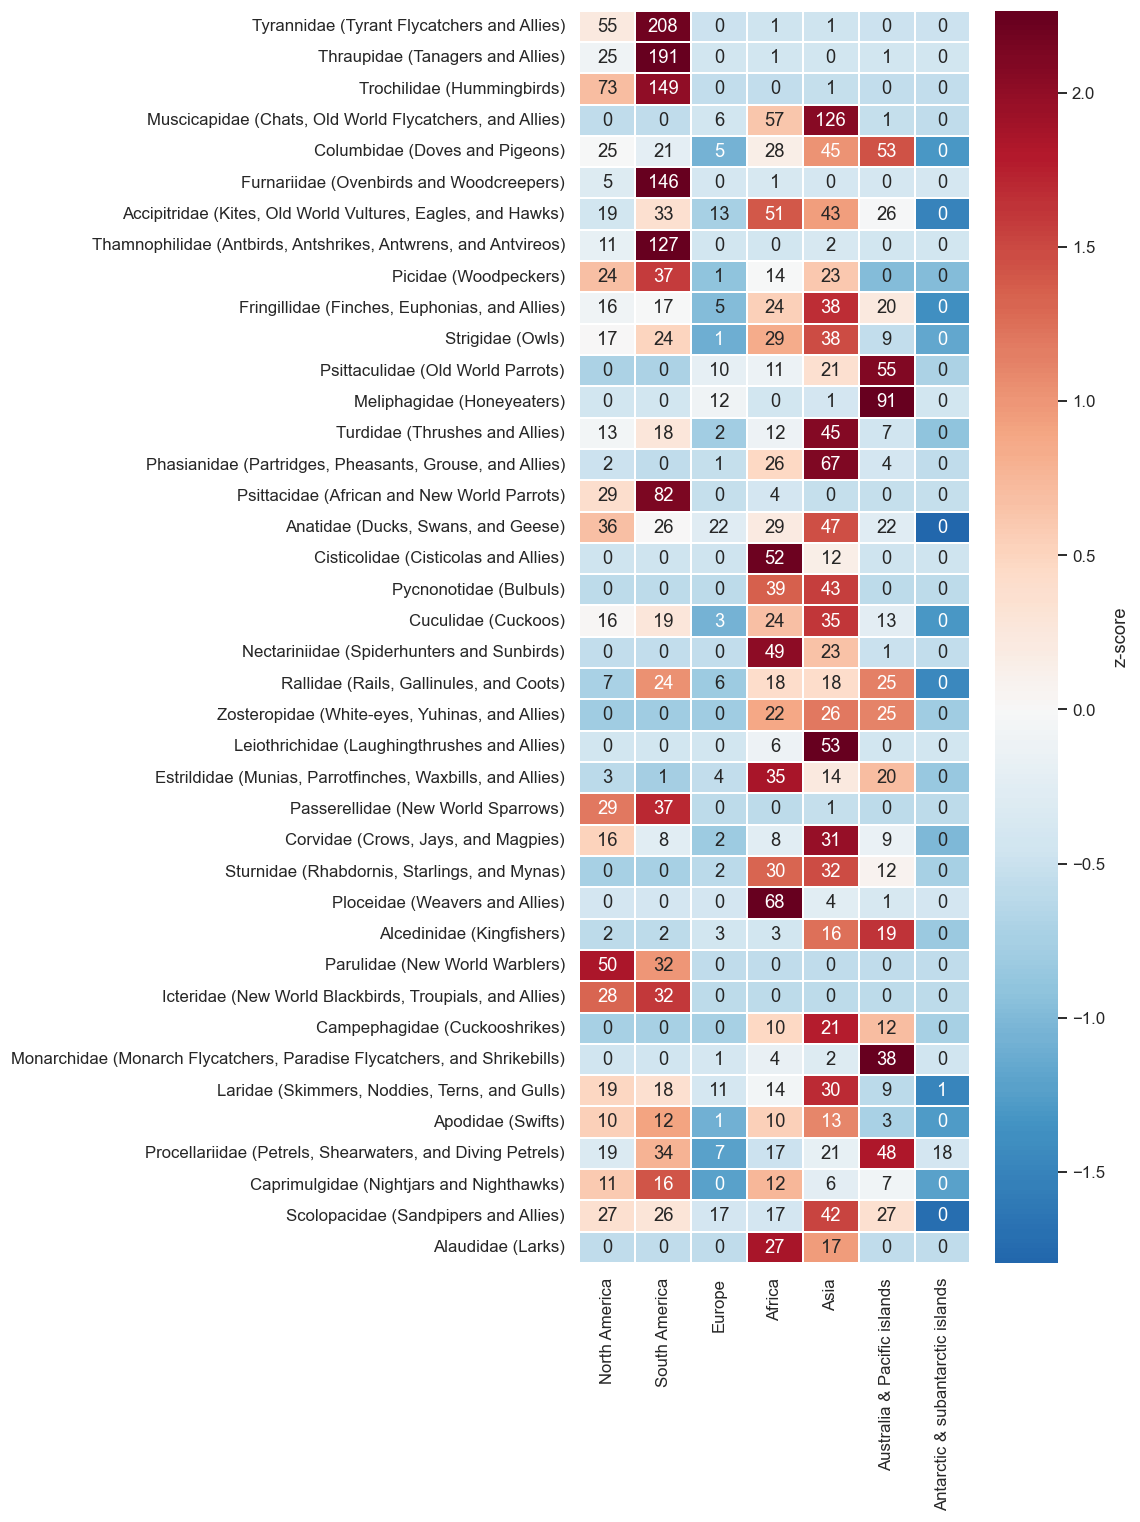

In [14]:
fc = (
    df_species[["Family", "Range_continents"]].explode("Range_continents")
    .dropna(subset=["Family", "Range_continents"]).rename(columns={"Range_continents": "Continent"})
)
fc_mat = fc.groupby(["Family", "Continent"]).size().unstack(fill_value=0)
fc_top = fc_mat.reindex(richest_families["Family"].head(40)).fillna(0)
_continent_plot_order = [
    "North America", "South America", "Europe", "Africa", "Asia", "Oceania", "Antarctic",
]
_cols = [c for c in _continent_plot_order if c in fc_top.columns]
_cols.extend([c for c in fc_top.columns if c not in _cols])
fc_top = fc_top[_cols]
fe = df_family.set_index("Scientific_name")["Family_English_name"].to_dict()
ytick = [family_label(f, fe.get(f, "")) for f in fc_top.index]
fc_z = fc_top.sub(fc_top.mean(1), 0).div(fc_top.std(1).replace(0, np.nan), 0).fillna(0)
xtick = [CONTINENT_DISPLAY.get(c, c) for c in fc_top.columns]
fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(
    fc_z, cmap="RdBu_r", center=0, annot=fc_top.astype(int), fmt="d", 
    cbar_kws={"label": "z-score"}, lw=0.3, ax=ax, 
    xticklabels=xtick, yticklabels=ytick
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


The first thing I noticed in the above plot is that the three most species-rich families (_Tyrannidae_, _Thraupidae_, and _Trochilidae_) are almost entirely over-represented in the New World, specifically in the Neotropics (Central + South America). Why is this? After some digging in the scientific literature, I found that the reason is largely due to geographic isolation; for tens of millions of years during the Cenozoic Era, South America was a massive island continent (similar to Australia today) allowing its ancestral bird species to evolve without competition from Old World birds with similar evolutionary adaptations. About 25 million years ago, geological upheaval formed the massive Andes mountain range fragmenting ecological niches into micro-climates and aggressively driving speciation of the ancestral Neotropic lineages. Add in the fact that just on the otherside of this massive mountain range was the Amazon rainforest, one of the most biodiverse areas on the entire planet, and South America became a hotspot for speciation. 

Traveling along Peru's Manu Road, a legendary spot for birding, up through the Andes, down through cloud forest, and ultimately to the Amazon river basin remains arguably the richest area on the planet for birding (certainly the most new species I've ever seen in such a small amount of time!). Around 3 million years ago, the Isthus of Panama rose from the sea, connecting South America and North America allowing these New World Lineages to spread up North (which is why we see a milder over-representation in North America compared to South America but an enrichment of both compared to other continents).

## 5) Conservation

I was curious about what the AviList's metadata could tell me about the conservation status of different bird lineages. To do this, I extracted threat and extinction codes across  global avifauna, using [IUCN Red List](https://www.iucnredlist.org/) status attached to each AviList species.

### Which orders are the most threatened?

Below I generated stacked bar plots representing every bird order (ranked by species count) and then colored percent of species by IUCN status.

/var/folders/99/lcs5c5z50pv845b2s0_pvzw40000gn/T/ipykernel_88614/13489930.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  iucn_by_order["total"] = iucn_by_order.sum(1)


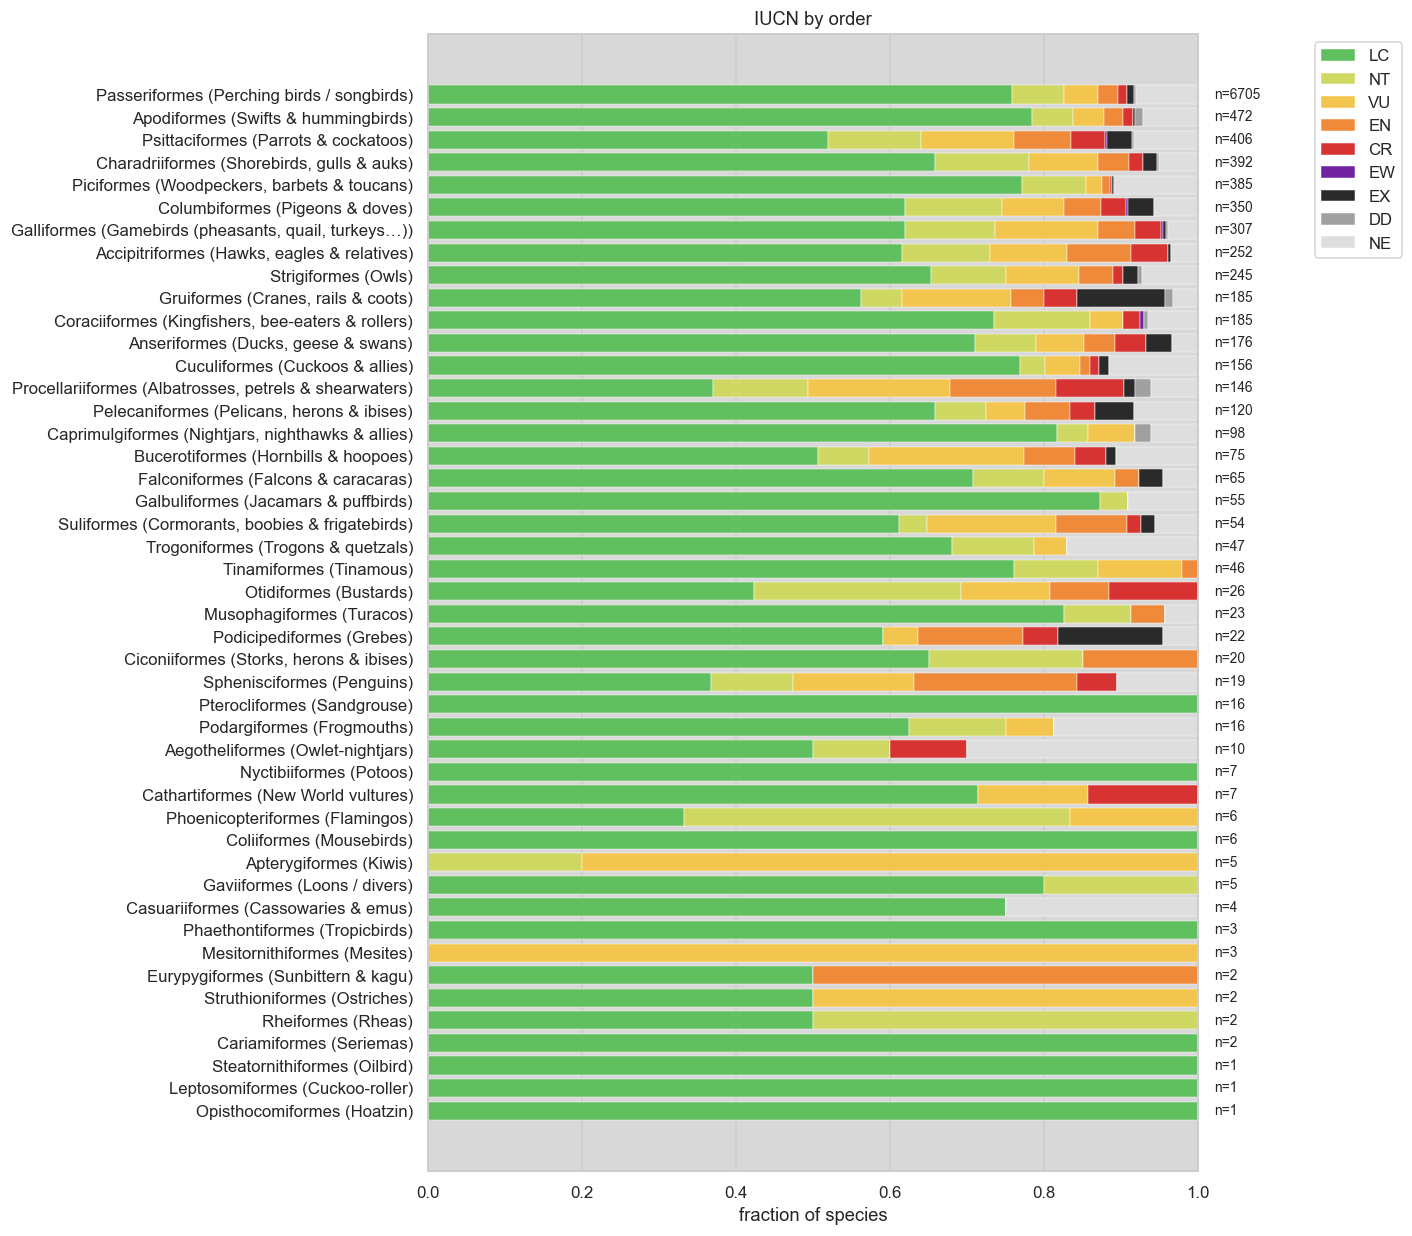

In [15]:
from matplotlib.patches import Rectangle

iucn_plot_order = ["LC", "NT", "VU", "EN", "CR", "EW", "EX", "DD", "NE"]
iucn_colors = {"LC": "#60c060", "NT": "#cfd862", "VU": "#f2c64e", "EN": "#ef8a3b", "CR": "#d83333", "EW": "#6f21a0", "EX": "#2a2a2a", "DD": "#a0a0a0", "NE": "#dedede"}
iucn_by_order = df_species.groupby(["Order", "IUCN"], observed=True).size().unstack(fill_value=0).reindex(columns=iucn_plot_order, fill_value=0)
iucn_by_order["total"] = iucn_by_order.sum(1)
iucn_by_order = iucn_by_order.sort_values("total", ascending=True)
frac = iucn_by_order.drop(columns=["total"]).div(iucn_by_order["total"], 0)
yl = [order_label(o) for o in frac.index]
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor("white")
bottom = np.zeros(len(frac))
for cat in iucn_plot_order:
    ax.barh(yl, frac[cat], left=bottom, color=iucn_colors[cat], label=cat, ec="white", lw=0.3)
    bottom += frac[cat].values
ax.set_xlim(0, 1)
ax.margins(x=0)
y0, y1 = ax.get_ylim()
y_lo, y_hi = min(y0, y1), max(y0, y1)
hatch_bg = Rectangle((0, y_lo), 1, y_hi - y_lo, facecolor="#d8d8d8", edgecolor="none", hatch="xx", zorder=0)
ax.add_patch(hatch_bg)
for p in ax.patches:
    if p is not hatch_bg:
        p.set_zorder(2)
for y_pos, n_sp in zip(range(len(yl)), iucn_by_order["total"]):
    ax.text(1.02, y_pos, f"n={int(n_sp)}", va="center", ha="left", fontsize=9, clip_on=False, zorder=3)
ax.set_xlabel("fraction of species")
ax.set_title("IUCN by order")
ax.legend(bbox_to_anchor=(1.14, 1), loc="upper left")
plt.tight_layout(rect=(0.02, 0.03, 0.88, 0.98))
plt.show()


**IUCN Red List legend**

| Code | Category | In plain English |
|------|----------|------------------|
| **LC** | Least concern | Not considered threatened at a global scale. |
| **NT** | Near threatened | Close to qualifying as threatened, or likely to become threatened. |
| **VU** | Vulnerable | High risk of extinction in the wild. |
| **EN** | Endangered | Very high risk of extinction in the wild. |
| **CR** | Critically endangered | Extremely high risk of extinction in the wild. |
| **EW** | Extinct in the wild | Only survives in captivity or outside its natural range. |
| **EX** | Extinct | No reasonable doubt the last wild individual is gone. |
| **DD** | Data deficient | Too little information to assess extinction risk. |
| **NE** | Not evaluated | Not yet assessed against Red List criteria (or missing / nonstandard values mapped here in this notebook). |

Each colored segment is the **fraction of species** in that order falling in that category; the value of `n=` on the right indicates the number of species in that order.

What's the takeaway from the above bar plot? Depressingly, it seems like virtually no bird order is immune from conservation risk. However, the most threatened orders (depending on how we calculate it) seem to be:
- **Gruiformes (cranes, rails, coots)**
- **Procellariiformes (albatrosses, petrels, shearwaters)**
- **Pelecaniformes (pelicans, herons, ibises)**
- **Podicipediformes (grebes)**

Interestingly, they all seem to be seabirds/shorebirds... When I dug into this a little further, a number of leading causes emerged from the literature:
- **climate change and habitat loss** (specifically wetland degradation)
- **high levels of bycatch** (longline fishing and gillnets)
- **"K-selection" as the evolutionary breeding strategy** (slow to reach sexual maturity with few young that require heavy investments)

Because I chose to plot the above visualization as percentage of total species within an order, some orders like Passeriformes look like they're doing relatively well in terms of conservation. However, in terms of total number of species under threat, the most threatened order actually is **Passeriformes**! At approximately 600 species under threat, 9% of Passeriformes have a Red List status ranging from Vulnerable to Extinct. To put this in perspective, ~600 species is more species than entirety of the next largest bird order (swifts and hummingbirds with n=472).

### Which orders have the most extinctions?

This becomes clear when we instead plot extinctions by order and see that the number of extinct passerines overwhelms the next most extinction-prone orders.

168 extinct / possibly extinct


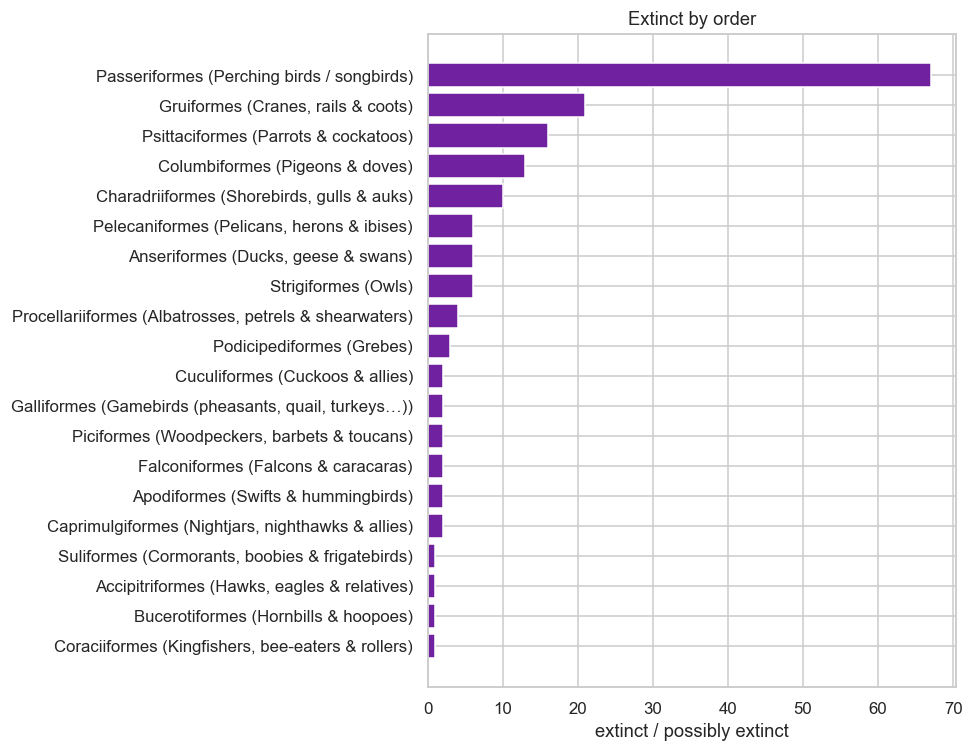

In [16]:
extinct = df_species[df_species["is_extinct"]].copy()
print(f"{len(extinct)} extinct / possibly extinct")
ext_by_order = extinct["Order"].value_counts().sort_values(ascending=True)
yl = [order_label(o) for o in ext_by_order.index]
fig, ax = plt.subplots(figsize=(9, max(4, len(ext_by_order) * 0.35)))
ax.barh(yl, ext_by_order.values, color="#6f21a0")
ax.set_xlabel("extinct / possibly extinct")
ax.set_title("Extinct by order")
plt.tight_layout()
plt.show()


So what can you and I do to help promote bird conservation and protect brids threatened by extinction?

- Support conservation oragnizations like the the [Cornell Lab of Ornithology](https://www.birds.cornell.edu/home/), [Birds Canada](https://www.birdscanada.org/), and the [Audubon Society](https://www.audubon.org/) by donating your money or time
- Practice ethical birding, and educate yourself and others
- Become a community scientist by logging your sightings on platforms like [eBird](https://ebird.org/home)
- Make windows safer by installing screens or applying decals (up to 1 billion birds die annually in North America alone from window collisions)
- Keep cats indoors (free-roaming domestic and feral cats kill billions of birds annually)
- Turn off your lights (especially during spring and fall migration seasons)

As with most of these data science posts, my main goal was to develop a deeper intuition for the subject matter and build some tools to help myself (and others) explore this rich dataset.

Hopefully you learned something and maybe even got excited about birding along the way.